In [1]:
import os
import glob
import zipfile
import librosa
import librosa.display
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from tqdm import tqdm
from scipy.stats import skew
from scipy.fft import rfft

sns.set_style("whitegrid")

# Path to ZIP file
ZIP_PATH = "/kaggle/input/notebooks/bytevance/coswara-extraction/coswara_breathing.zip"

# Extraction directory
EXTRACT_PATH = "/kaggle/working/coswara_breathing"

# Extract only once
if not os.path.exists(EXTRACT_PATH):
    os.makedirs(EXTRACT_PATH, exist_ok=True)

    with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
        zip_ref.extractall(EXTRACT_PATH)

    print("Extraction complete.")

# Load WAV files
audio_files = [
    os.path.join(EXTRACT_PATH, f)
    for f in os.listdir(EXTRACT_PATH)
    if f.endswith(".wav")
]

print(f"Total breathing recordings: {len(audio_files)}")

# Preview a few files
print("\nSample files:")
for f in audio_files[:5]:
    print(os.path.basename(f))

Extraction complete.
Total breathing recordings: 662

Sample files:
VlQvT9LEVHMLQq3GSPkH4vyskW83_breathing-shallow.wav
GWjZnz8QWXXGzHLaG0HNHFyeZgS2_breathing-shallow.wav
AeJcnB6Pl6ayw2YL7whgWyYSVnz2_breathing-deep.wav
P5mI5OKQZ3WbFo8FkU7VuvAwUwz2_breathing-shallow.wav
HwUhcAKwJIeckUi86cbzb3sTr5m2_breathing-shallow.wav


In [2]:
# Get a list of deep and shallow breathing files
deep_files = glob.glob(os.path.join(EXTRACT_PATH, "*_breathing-deep.wav"))
shallow_files = glob.glob(os.path.join(EXTRACT_PATH, "*_breathing-shallow.wav"))

print(f"Found {len(deep_files)} deep breathing and {len(shallow_files)} shallow breathing files for visualization.")

Found 333 deep breathing and 329 shallow breathing files for visualization.


100%|██████████| 662/662 [00:22<00:00, 29.71it/s] 


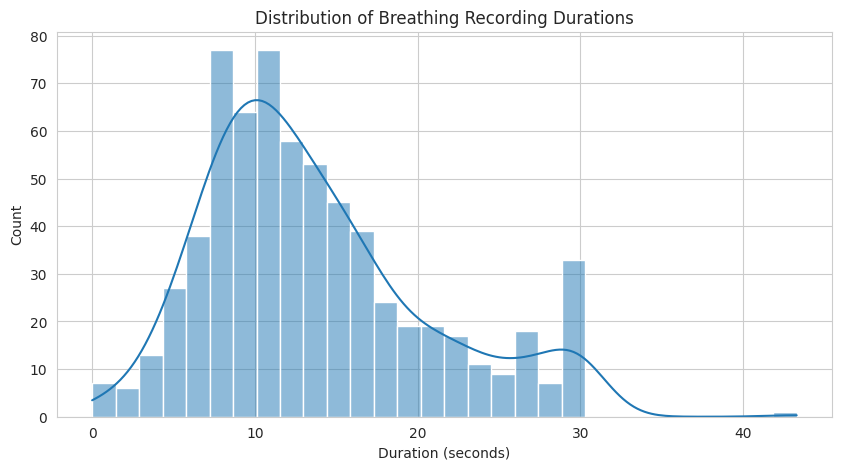

In [3]:
durations = []

for file in tqdm(audio_files):

    y, sr = librosa.load(file,sr=None)

    durations.append(len(y)/sr)

plt.figure(figsize=(10,5))

sns.histplot(
    durations,
    bins=30,
    kde=True
)

plt.title("Distribution of Breathing Recording Durations")
plt.xlabel("Duration (seconds)")
plt.ylabel("Count")

plt.show()

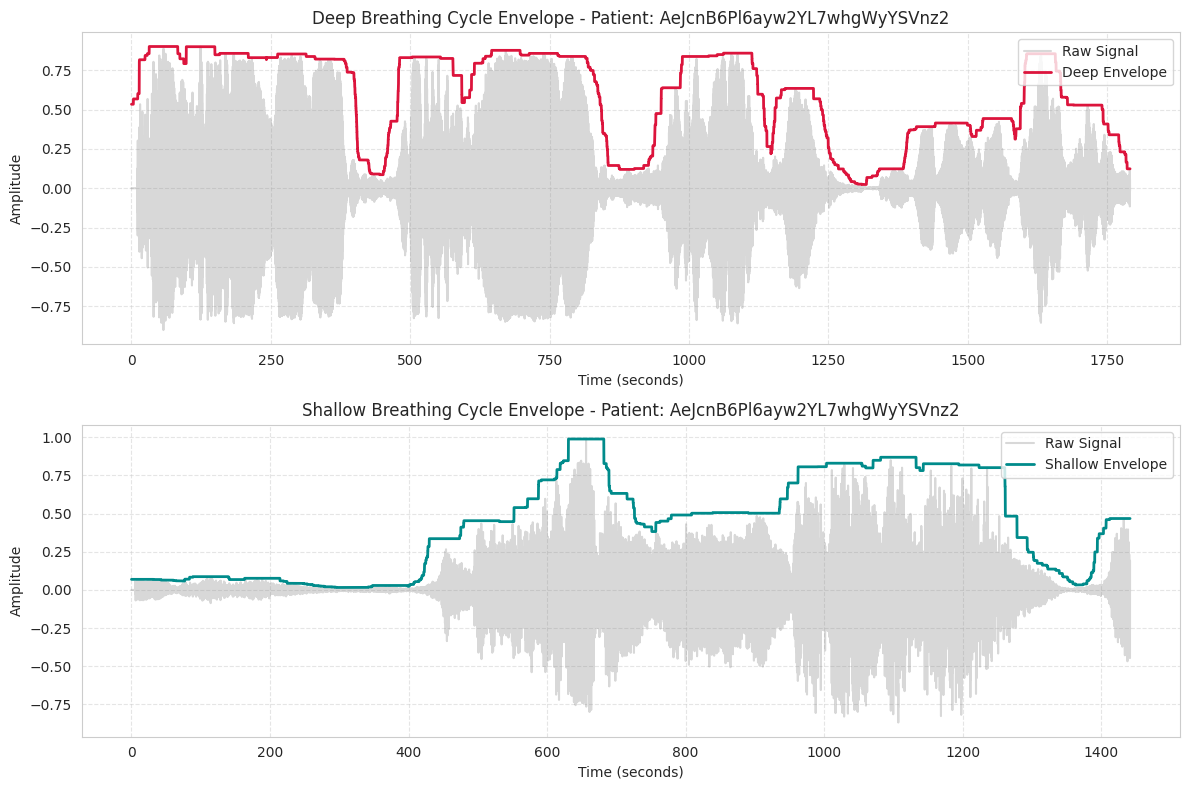

In [4]:
def plot_combined_breathing_envelopes_fixed(deep_file_path, shallow_file_path):
    fig, axes = plt.subplots(2, 1, figsize=(12, 8))
    
    files = [deep_file_path, shallow_file_path]
    types = ["Deep", "Shallow"]
    colors = ["crimson", "darkcyan"]
    
    for i, (file_path, b_type, color) in enumerate(zip(files, types, colors)):
        y, sr = librosa.load(file_path, sr=16000)
        
        # Check if the file is silent or empty
        if np.max(np.abs(y)) < 1e-4:
            axes[i].text(0.5, 0.5, f"Warning: {b_type} audio file is silent/empty", 
                         ha='center', va='center', fontsize=14, color='red')
            axes[i].set_title(f"{b_type} Breathing - Empty File")
            continue
            
        times_raw = librosa.times_like(y, sr=sr)
        
        # Vectorized rolling max for the envelope (keeps arrays the exact same length!)
        window_size = int(sr * 0.1) # 100ms window
        # Pad the signal so the output matches the original length perfectly
        padded_y = np.pad(np.abs(y), (window_size//2, window_size//2), mode='edge')
        
        # Fast rolling max trick using NumPy stride tricks or a uniform filter
        from scipy.ndimage import maximum_filter1d
        amplitude_envelope = maximum_filter1d(np.abs(y), size=window_size)
        
        # Plot raw signal and envelope using the exact same time array
        axes[i].plot(times_raw, y, alpha=0.3, label='Raw Signal', color='gray')
        axes[i].plot(times_raw, amplitude_envelope, color=color, linewidth=2, label=f'{b_type} Envelope')
        
        patient_id = os.path.basename(file_path).split('_')[0]
        axes[i].set_title(f"{b_type} Breathing Cycle Envelope - Patient: {patient_id}", fontsize=12)
        axes[i].set_ylabel("Amplitude")
        axes[i].set_xlabel("Time (seconds)")
        axes[i].legend(loc='upper right')
        axes[i].grid(True, linestyle='--', alpha=0.5)
        
    plt.tight_layout()
    plt.show()

# --- Find a Patient with non-empty files ---
# Let's loop through files until we find a pair that actually has audio data
found_valid_pair = False
for deep_file in deep_files:
    target_patient = os.path.basename(deep_file).split('_')[0]
    matching_shallow = [f for f in shallow_files if target_patient in os.path.basename(f)]
    
    if matching_shallow:
        # Quick check if both files have actual sound data
        y_d, _ = librosa.load(deep_file, sr=16000)
        y_s, _ = librosa.load(matching_shallow[0], sr=16000)
        
        if np.max(np.abs(y_d)) > 0.01 and np.max(np.abs(y_s)) > 0.01:
            plot_combined_breathing_envelopes_fixed(deep_file, matching_shallow[0])
            found_valid_pair = True
            break

if not found_valid_pair:
    print("Could not find a patient with two non-silent files in the initial sweep. Running fallback on first items:")
    plot_combined_breathing_envelopes_fixed(deep_files[0], shallow_files[0])

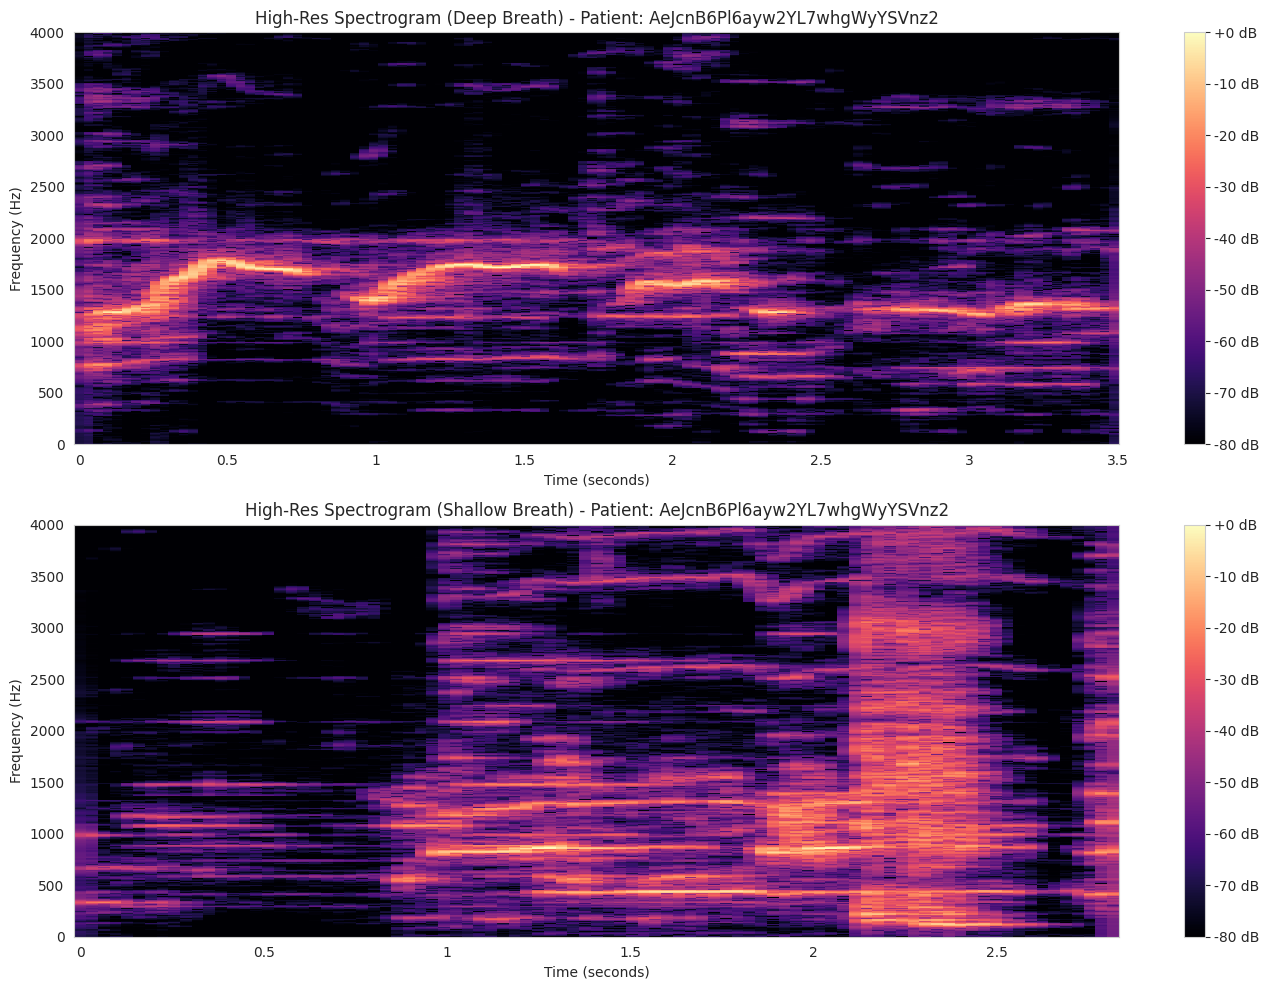

In [5]:
def plot_combined_spectrograms(deep_file_path, shallow_file_path):
    # Set up a 2-row subplot canvas
    fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=False)
    
    files = [deep_file_path, shallow_file_path]
    types = ["Deep", "Shallow"]
    
    for i, (file_path, b_type) in enumerate(zip(files, types)):
        # Load audio
        y, sr = librosa.load(file_path, sr=16000)
        
        # Handle empty/silent files gracefully
        if np.max(np.abs(y)) < 1e-4:
            axes[i].text(0.5, 0.5, f"Warning: {b_type} audio file is silent/empty", 
                         ha='center', va='center', fontsize=14, color='red')
            axes[i].set_title(f"High-Res Spectrogram ({b_type} Breath) - Empty File")
            continue
            
        # Generate Short-Time Fourier Transform (STFT)
        stft = librosa.stft(y, n_fft=2048, hop_length=512)
        stft_db = librosa.amplitude_to_db(np.abs(stft), ref=np.max)
        
        # Display the spectrogram on the current subplot
        img = librosa.display.specshow(stft_db, sr=sr, hop_length=512, 
                                      x_axis='time', y_axis='linear', 
                                      cmap='magma', ax=axes[i])
        
        # Add color bar to each subplot to track decibel levels
        fig.colorbar(img, ax=axes[i], format='%+2.0f dB')
        
        patient_id = os.path.basename(file_path).split('_')[0]
        axes[i].set_title(f"High-Res Spectrogram ({b_type} Breath) - Patient: {patient_id}", fontsize=12)
        axes[i].set_xlabel("Time (seconds)")
        axes[i].set_ylabel("Frequency (Hz)")
        
        # Restrict focus to human breathing range (0 - 4000 Hz)
        axes[i].set_ylim(0, 4000)
        
    plt.tight_layout()
    plt.show()

# --- Execution Logic with Patient Pairing & Silence Detection ---
found_valid_pair = False
for deep_file in deep_files:
    target_patient = os.path.basename(deep_file).split('_')[0]
    matching_shallow = [f for f in shallow_files if target_patient in os.path.basename(f)]
    
    if matching_shallow:
        # Load briefly to check they aren't flat silent lines
        y_d, _ = librosa.load(deep_file, sr=16000)
        y_s, _ = librosa.load(matching_shallow[0], sr=16000)
        
        # Ensure both recordings have actual substantial audio data
        if np.max(np.abs(y_d)) > 0.01 and np.max(np.abs(y_s)) > 0.01:
            plot_combined_spectrograms(deep_file, matching_shallow[0])
            found_valid_pair = True
            break

if not found_valid_pair:
    print("Could not find a perfect non-silent pair. Running fallback on first entries:")
    plot_combined_spectrograms(deep_files[0], shallow_files[0])

Extracting features from file samples...


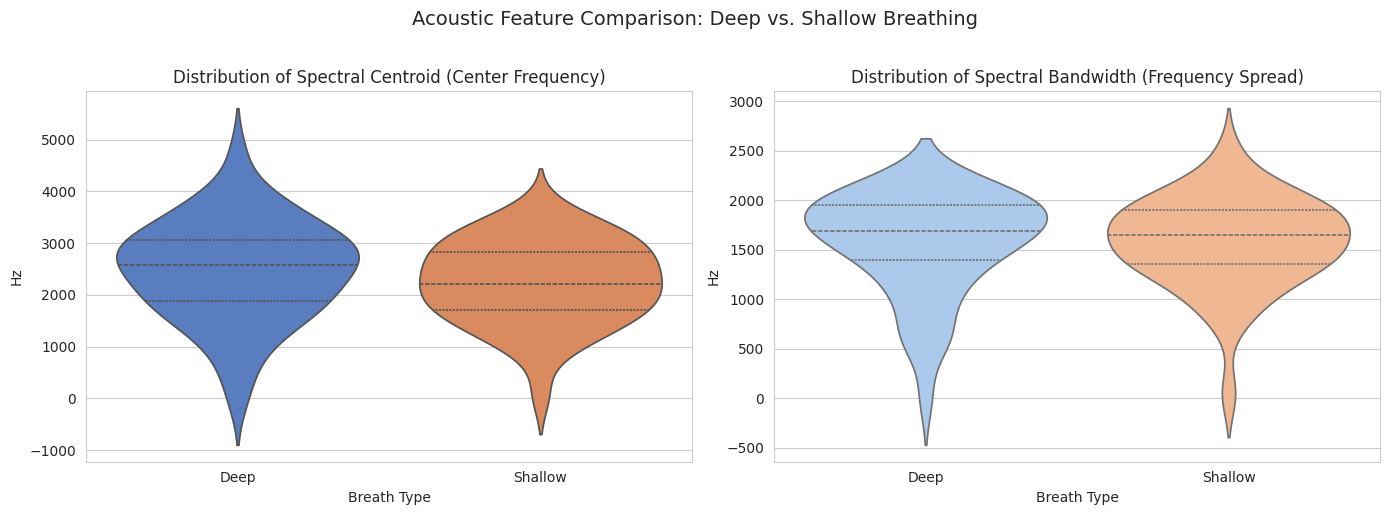

In [6]:
def extract_spectral_features(file_list, label):
    features = []
    # Limit to 40 files for quick EDA plotting, increase if you want to map all
    for file_path in file_list[:40]: 
        try:
            y, sr = librosa.load(file_path, sr=16000)
            if len(y) == 0: continue
            
            # Extract features
            centroid = librosa.feature.spectral_centroid(y=y, sr=sr)[0]
            bandwidth = librosa.feature.spectral_bandwidth(y=y, sr=sr)[0]
            
            features.append({
                'Spectral Centroid': np.mean(centroid),
                'Spectral Bandwidth': np.mean(bandwidth),
                'Breath Type': label
            })
        except Exception as e:
            # Skip corrupted audio files safely
            continue
    return features

# Extract features from subsets of your data
print("Extracting features from file samples...")
deep_features = extract_spectral_features(deep_files, 'Deep')
shallow_features = extract_spectral_features(shallow_files, 'Shallow')

# Combine into a single pandas DataFrame
df_features = pd.DataFrame(deep_features + shallow_features)

# Plotting Violin Plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Fixed with explicitly matched hue and legend assignments
sns.violinplot(data=df_features, x='Breath Type', y='Spectral Centroid', hue='Breath Type',
               ax=axes[0], palette='muted', inner="quart", legend=False)
axes[0].set_title('Distribution of Spectral Centroid (Center Frequency)')
axes[0].set_ylabel('Hz')

sns.violinplot(data=df_features, x='Breath Type', y='Spectral Bandwidth', hue='Breath Type',
               ax=axes[1], palette='pastel', inner="quart", legend=False)
axes[1].set_title('Distribution of Spectral Bandwidth (Frequency Spread)')
axes[1].set_ylabel('Hz')

plt.suptitle("Acoustic Feature Comparison: Deep vs. Shallow Breathing", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# 1. Scale and run PCA on your complete feature matrix X (662 samples)
X_scaled = StandardScaler().fit_transform(X)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# 2. Build a matching labels array based on the true number of files
# (This ensures the sizes match perfectly)
labels = np.array(['Deep Breathing'] * len(deep_files) + ['Shallow Breathing'] * len(shallow_files))

# 3. Plotting using a clean dictionary mapping for categories
plt.figure(figsize=(10, 8))

for target_label, color, marker in zip(['Deep Breathing', 'Shallow Breathing'], ['crimson', 'darkcyan'], ['o', 's']):
    # Find the row indices where this label matches
    indices_to_plot = np.where(labels == target_label)
    
    plt.scatter(
        X_pca[indices_to_plot, 0], 
        X_pca[indices_to_plot, 1], 
        c=color, 
        label=target_label,
        alpha=0.6,
        marker=marker,
        edgecolors='w',
        linewidth=0.5
    )

# 4. Final Polish
plt.title("PCA of Breathing MFCC Features", fontsize=14)
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% Variance Explained)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% Variance Explained)")
plt.legend(loc='upper right', title="Breath Type")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

NameError: name 'X' is not defined